# Berlin Airbnb Market Overview

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
main_df = pd.read_csv('../data/listings.csv')
main_df.info()
main_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            14274 non-null  int64  
 1   listing_url                                   14274 non-null  str    
 2   scrape_id                                     14274 non-null  int64  
 3   last_scraped                                  14274 non-null  str    
 4   source                                        14274 non-null  str    
 5   name                                          14274 non-null  str    
 6   description                                   13712 non-null  str    
 7   neighborhood_overview                         6474 non-null   str    
 8   picture_url                                   14274 non-null  str    
 9   host_id                                       14274 non-null  int64  
 1

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20250923202926,2025-09-24,city scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,The neighbourhood is famous for its variety of...,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,f,1,1,0,0,0.76
1,9991,https://www.airbnb.com/rooms/9991,20250923202926,2025-09-24,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,Prenzlauer Berg is an amazing neighbourhood wh...,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,f,1,1,0,0,0.06
2,14325,https://www.airbnb.com/rooms/14325,20250923202926,2025-09-24,city scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/508703/24988a...,55531,...,4.85,4.60,4.45,NaN,f,4,4,0,0,0.14
3,17904,https://www.airbnb.com/rooms/17904,20250923202926,2025-09-24,city scrape,Beautiful Kreuzberg studio - 3 months minimum,"- apt is available starting October 1, 2025 (m...","The apartment is located in Kreuzberg, which i...",https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,f,1,1,0,0,1.57
4,20858,https://www.airbnb.com/rooms/20858,20250923202926,2025-09-24,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,Fantastic vibe in the middle of the popular Ka...,https://a0.muscache.com/pictures/108232/205b19...,71331,...,4.54,4.91,4.39,03/Z/RA/009767-24,f,1,1,0,0,0.89


In [3]:
subset = main_df.copy()
subset = subset[['id', 'neighbourhood_group_cleansed', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type', 'price', 'number_of_reviews', 'reviews_per_month', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'review_scores_rating']]
subset.info()
subset.head()

<class 'pandas.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            14274 non-null  int64  
 1   neighbourhood_group_cleansed  14274 non-null  str    
 2   neighbourhood_cleansed        14274 non-null  str    
 3   latitude                      14274 non-null  float64
 4   longitude                     14274 non-null  float64
 5   room_type                     14274 non-null  str    
 6   price                         9264 non-null   str    
 7   number_of_reviews             14274 non-null  int64  
 8   reviews_per_month             10960 non-null  float64
 9   estimated_occupancy_l365d     14274 non-null  int64  
 10  estimated_revenue_l365d       9264 non-null   float64
 11  review_scores_rating          10960 non-null  float64
dtypes: float64(5), int64(3), str(4)
memory usage: 1.3 MB


,id,neighbourhood_group_cleansed,neighbourhood_cleansed,latitude,longitude,room_type,price,number_of_reviews,reviews_per_month,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating
0,3176,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,$105.00,150,0.76,252,26460.0,4.63
1,9991,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,$135.00,7,0.06,0,0.0,5.00
2,14325,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,$75.00,26,0.14,0,0.0,4.68
3,17904,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,$32.00,298,1.57,186,5952.0,4.77
4,20858,Pankow,Prenzlauer Berg Südwest,52.53711,13.40888,Entire home/apt,$202.00,140,0.89,50,10100.0,4.48


In [4]:
# Cleaning price (removing '$' and thousands separator ',') and changing data type
subset['price'] = (
    subset['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)
subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            14274 non-null  int64  
 1   neighbourhood_group_cleansed  14274 non-null  str    
 2   neighbourhood_cleansed        14274 non-null  str    
 3   latitude                      14274 non-null  float64
 4   longitude                     14274 non-null  float64
 5   room_type                     14274 non-null  str    
 6   price                         9264 non-null   float64
 7   number_of_reviews             14274 non-null  int64  
 8   reviews_per_month             10960 non-null  float64
 9   estimated_occupancy_l365d     14274 non-null  int64  
 10  estimated_revenue_l365d       9264 non-null   float64
 11  review_scores_rating          10960 non-null  float64
dtypes: float64(6), int64(3), str(3)
memory usage: 1.3 MB


In [5]:
# Filling missing 'price' values with the median in each neighbourhood/room_type bucket
subset['price'] = subset.groupby(['neighbourhood_cleansed', 'room_type'])['price'].transform(lambda x: x.fillna(x.median()))
subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 14274 entries, 0 to 14273
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            14274 non-null  int64  
 1   neighbourhood_group_cleansed  14274 non-null  str    
 2   neighbourhood_cleansed        14274 non-null  str    
 3   latitude                      14274 non-null  float64
 4   longitude                     14274 non-null  float64
 5   room_type                     14274 non-null  str    
 6   price                         14270 non-null  float64
 7   number_of_reviews             14274 non-null  int64  
 8   reviews_per_month             10960 non-null  float64
 9   estimated_occupancy_l365d     14274 non-null  int64  
 10  estimated_revenue_l365d       9264 non-null   float64
 11  review_scores_rating          10960 non-null  float64
dtypes: float64(6), int64(3), str(3)
memory usage: 1.3 MB


In [6]:
# Dropping 4 un-imputable edge cases as it would constitute a loss of only 0.028% of the data
subset = subset.dropna(subset=['price'])

# Confirming data completeness
print(subset.isnull().sum())

id                                 0
neighbourhood_group_cleansed       0
neighbourhood_cleansed             0
latitude                           0
longitude                          0
room_type                          0
price                              0
number_of_reviews                  0
reviews_per_month               3313
estimated_occupancy_l365d          0
estimated_revenue_l365d         5006
review_scores_rating            3313
dtype: int64


In [7]:
# Recalculating only missing estimated_revenue_l365d values cleanly based on existing component metrics
missing_rev_mask = subset['estimated_revenue_l365d'].isnull()
subset.loc[missing_rev_mask, 'estimated_revenue_l365d'] = (
    subset.loc[missing_rev_mask, 'price'] * subset.loc[missing_rev_mask, 'estimated_occupancy_l365d']
)
# Confirming data completeness
print(subset.isnull().sum())

# Lastly, reviews will remain untouched as they are likely brand new listings

id                                 0
neighbourhood_group_cleansed       0
neighbourhood_cleansed             0
latitude                           0
longitude                          0
room_type                          0
price                              0
number_of_reviews                  0
reviews_per_month               3313
estimated_occupancy_l365d          0
estimated_revenue_l365d            0
review_scores_rating            3313
dtype: int64


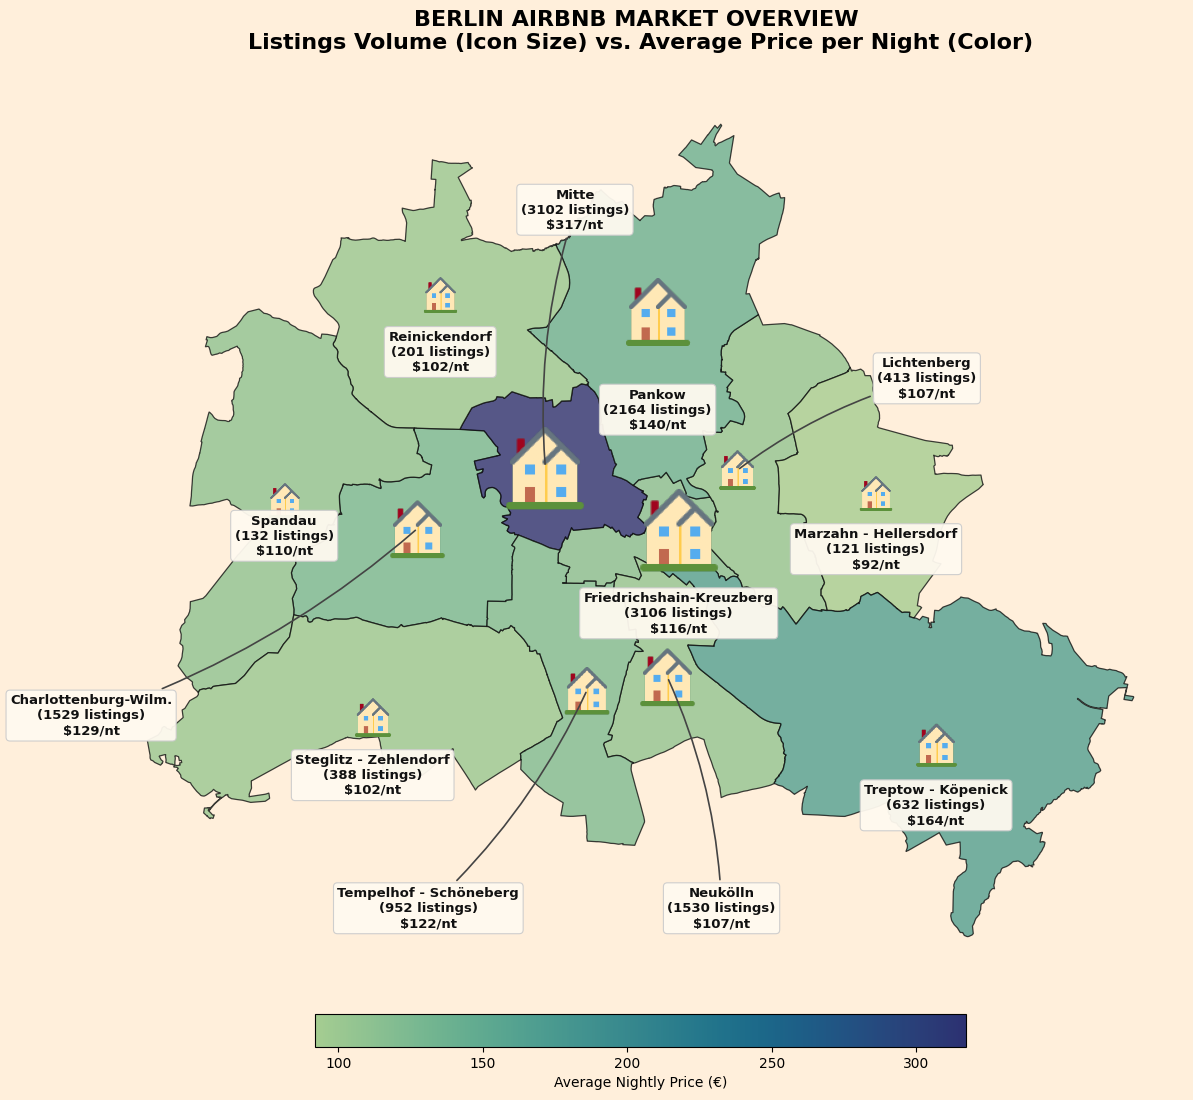

In [10]:
import io
import urllib.request
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import seaborn as sns

# 1. Fetch the Twitter Emoji Asset (house glyph)
emoji_url = (
    "https://cdnjs.cloudflare.com/ajax/libs/twemoji/14.0.2/72x72/1f3e0.png"
)
try:
    req = urllib.request.Request(emoji_url, headers={"User-Agent": "Mozilla"})
    with urllib.request.urlopen(req) as response:
        img_file = io.BytesIO(response.read())
    house_img = plt.imread(img_file, format="png")
except Exception:
    import numpy as np

    house_img = np.ones((32, 32, 4))

# 2. Data Preparation
df_borough_stats = (
    subset.groupby("neighbourhood_group_cleansed")
    .agg(price=("price", "mean"), listing_count=("id", "count"))
    .reset_index()
)

# FIXED: Added .reset_index() to keep 'neighbourhood_group' as a column
gdf_shapes = gpd.read_file("../data/neighbourhoods.geojson")  # update path as needed)
gdf_borough_shapes = gdf_shapes.dissolve(by="neighbourhood_group").reset_index()

gdf_borough_map = gdf_borough_shapes.merge(
    df_borough_stats,
    left_on="neighbourhood_group",
    right_on="neighbourhood_group_cleansed",
)

# 3. Canvas Construction with Cool-Warm high-contrast palette
fig, ax = plt.subplots(1, 1, figsize=(14, 16), facecolor="#ffefdb")

# Layer 1: Choropleth (Color = Price)
gdf_borough_map.plot(
    column="price",
    cmap=sns.color_palette("crest", as_cmap=True),
    ax=ax,
    edgecolor="#111111",
    linewidth=0.9,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "label": "Average Nightly Price (€)",
        "orientation": "horizontal",
        "pad": 0.03,
        "shrink": 0.6,
    },
)

# 4. Optimized Position Dictionaries
# Removed Friedrichshain-Kreuzberg to let it drop natively below its icon
# Added Lichtenberg to map into the clear Northeast quadrant
callout_positions = {
    "Mitte": (13.38, 52.64),
    "Neukölln": (13.48, 52.35),
    "Charlottenburg-Wilm.": (13.05, 52.43),
    "Tempelhof - Schöneberg": (13.28, 52.35),
    "Lichtenberg": (13.62, 52.57),  # Pushed Northeast above Marzahn
}

# Fine-tuning local standard offsets for standard peripheral text cards
label_overrides = {
    "Pankow": (0, -55),
    "Spandau": (0, -10),
    "Friedrichshain-Kreuzberg": (
        0,
        -45,
    ),  # Tucked perfectly beneath its house glyph
}

max_count = gdf_borough_map["listing_count"].max()

# 5. Iconography and Text Placement Loop
for idx, row in gdf_borough_map.iterrows():
    b_name = row["neighbourhood_group"]
    coords = row["geometry"].representative_point().coords[0]

    # Render Emoji Glyph
    scaled_zoom = 0.35 + (row["listing_count"] / max_count) * 0.55
    image_box = OffsetImage(house_img, zoom=scaled_zoom)
    ab = AnnotationBbox(image_box, coords, frameon=False, zorder=3)
    ax.add_artist(ab)

    # Informational Text Card
    label_text = (
        f"{b_name}\n({row['listing_count']} listings)\n${row['price']:.0f}/nt"
    )

    # CASE A: Special Callout Pointer Lines (Atlas Style)
    if b_name in callout_positions:
        ax.annotate(
            text=label_text,
            xy=coords,  # Pointer arrow destination (house icon)
            xytext=callout_positions[b_name],  # Floating label destination
            textcoords="data",
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=9.5,
            fontweight="bold",
            color="#111111",
            bbox=dict(
                boxstyle="round,pad=0.3",
                fc="#fffaf0",
                ec="#cccccc",
                lw=0.8,
                alpha=0.95,
            ),
            arrowprops=dict(
                arrowstyle="-",  # Clean, minimalist pointer line
                color="#444444",
                linewidth=1.2,
                connectionstyle="arc3,rad=0.1",  # Subtle organic curve to the connector
                zorder=2,
            ),
            zorder=4,
        )

    # CASE B: Standard Peripheral Placement (Outer Boroughs)
    else:
        # Determine standard offset or specific override (e.g., Pankow)
        standard_offset = 12 + (scaled_zoom * 35)
        label_offset = label_overrides.get(
            b_name, (0, -standard_offset)
        )  # (x,y) tuple

        ax.annotate(
            text=label_text,
            xy=coords,  # Anchor to house center
            xytext=label_offset,
            textcoords="offset points",
            horizontalalignment="center",
            verticalalignment="top",  # Card hangs *below* the anchor
            fontsize=9.5,
            fontweight="bold",
            color="#111111",
            bbox=dict(
                boxstyle="round,pad=0.3",
                fc="#fffaf0",
                ec="#cccccc",
                lw=0.8,
                alpha=0.95,
            ),
            zorder=4,
        )

# Map polishing
ax.set_axis_off()
plt.title(
    "BERLIN AIRBNB MARKET OVERVIEW \nListings Volume (Icon Size) vs. Average Price per Night (Color)",
    fontsize=16,
    fontweight="bold",
    pad=25,
)
plt.savefig('berlin_airbnb_market_overview.png', dpi=150, bbox_inches='tight')
plt.show()